In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the saved arrays from Week 3
X_train = np.load('X_train.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

print("Data loaded!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Data loaded!
X_train shape: (2307028, 20)
X_test shape: (576758, 20)
y_train shape: (2307028,)
y_test shape: (576758,)


In [2]:
from sklearn.tree import DecisionTreeClassifier
import time

# Create and train the model
dt_model = DecisionTreeClassifier(random_state=42)

print("Training Decision Tree...")
start_time = time.time()
dt_model.fit(X_train, y_train)
end_time = time.time()

print(f"Training completed in {end_time - start_time:.2f} seconds")

Training Decision Tree...
Training completed in 17.12 seconds


In [3]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on test data
y_pred_dt = dt_model.predict(X_test)

# Check accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt * 100:.2f}%")

print("\nDetailed Report:")
print(classification_report(y_test, y_pred_dt, target_names=['BENIGN', 'FTP-Patator', 'SSH-Patator']))

Decision Tree Accuracy: 100.00%

Detailed Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    192173
 FTP-Patator       1.00      1.00      1.00    192158
 SSH-Patator       1.00      1.00      1.00    192427

    accuracy                           1.00    576758
   macro avg       1.00      1.00      1.00    576758
weighted avg       1.00      1.00      1.00    576758



In [4]:
# Reload original (pre-SMOTE) data
df = pd.read_csv('combined_dataset.csv')

# Clean it the same way as before
df = df[df[' Flow Duration'] >= 0]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df[' Label'] = le.fit_transform(df[' Label'])

print("Reloaded and cleaned. Shape:", df.shape)

Reloaded and cleaned. Shape: (975094, 79)


In [5]:
top_features = pd.read_csv('top_features.csv')['0'].tolist()

X = df[top_features]
y = df[' Label']

from sklearn.model_selection import train_test_split

# Split BEFORE SMOTE this time
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)
print("\nTrain label counts:")
print(y_train_raw.value_counts())

Before SMOTE:
Train shape: (780075, 20)
Test shape: (195019, 20)

Train label counts:
 Label
0    769009
1      6348
2      4718
Name: count, dtype: int64


In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_raw, y_train_raw)

print("After SMOTE (training only):")
print(pd.Series(y_train_balanced).value_counts())

print("\nTest set remains UNTOUCHED:")
print(y_test_raw.value_counts())

After SMOTE (training only):
 Label
0    769009
2    769009
1    769009
Name: count, dtype: int64

Test set remains UNTOUCHED:
 Label
0    192253
1      1587
2      1179
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test_raw)

print("Scaling done correctly!")
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Scaling done correctly!
Train shape: (2307027, 20)
Test shape: (195019, 20)


In [8]:
from sklearn.tree import DecisionTreeClassifier
import time

dt_model = DecisionTreeClassifier(random_state=42)

print("Training Decision Tree (correct way)...")
start_time = time.time()
dt_model.fit(X_train_scaled, y_train_balanced)
end_time = time.time()

print(f"Training completed in {end_time - start_time:.2f} seconds")

Training Decision Tree (correct way)...
Training completed in 10.08 seconds


In [9]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_dt = dt_model.predict(X_test_scaled)

accuracy_dt = accuracy_score(y_test_raw, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt * 100:.2f}%")

print("\nDetailed Report:")
print(classification_report(y_test_raw, y_pred_dt, target_names=['BENIGN', 'FTP-Patator', 'SSH-Patator']))

Decision Tree Accuracy: 100.00%

Detailed Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    192253
 FTP-Patator       1.00      1.00      1.00      1587
 SSH-Patator       1.00      1.00      1.00      1179

    accuracy                           1.00    195019
   macro avg       1.00      1.00      1.00    195019
weighted avg       1.00      1.00      1.00    195019



In [10]:
from sklearn.model_selection import cross_val_score

# Quick cross validation on a sample (full data would take long)
sample_idx = np.random.choice(len(X_train_scaled), 100000, replace=False)
X_sample = X_train_scaled[sample_idx]
y_sample = y_train_balanced.iloc[sample_idx] if hasattr(y_train_balanced, 'iloc') else y_train_balanced[sample_idx]

scores = cross_val_score(dt_model, X_sample, y_sample, cv=5)
print("Cross-validation scores:", scores)
print(f"Average: {scores.mean()*100:.2f}%")

Cross-validation scores: [1.      0.99995 0.99985 0.9999  0.99995]
Average: 99.99%


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("Training Random Forest...")
start_time = time.time()
rf_model.fit(X_train_scaled, y_train_balanced)
end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds")

y_pred_rf = rf_model.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test_raw, y_pred_rf)
print(f"\nRandom Forest Accuracy: {accuracy_rf * 100:.2f}%")

Training Random Forest...
Training completed in 20.61 seconds

Random Forest Accuracy: 100.00%


In [12]:
from sklearn.neighbors import KNeighborsClassifier

# Use a sample for KNN since it's slow on large datasets
sample_idx = np.random.choice(len(X_train_scaled), 200000, replace=False)
X_train_knn = X_train_scaled[sample_idx]
y_train_knn = y_train_balanced.iloc[sample_idx] if hasattr(y_train_balanced, 'iloc') else y_train_balanced[sample_idx]

knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

print("Training KNN...")
start_time = time.time()
knn_model.fit(X_train_knn, y_train_knn)
end_time = time.time()
print(f"Training completed in {end_time - start_time:.2f} seconds")

y_pred_knn = knn_model.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test_raw, y_pred_knn)
print(f"\nKNN Accuracy: {accuracy_knn * 100:.2f}%")

Training KNN...
Training completed in 0.02 seconds

KNN Accuracy: 99.84%


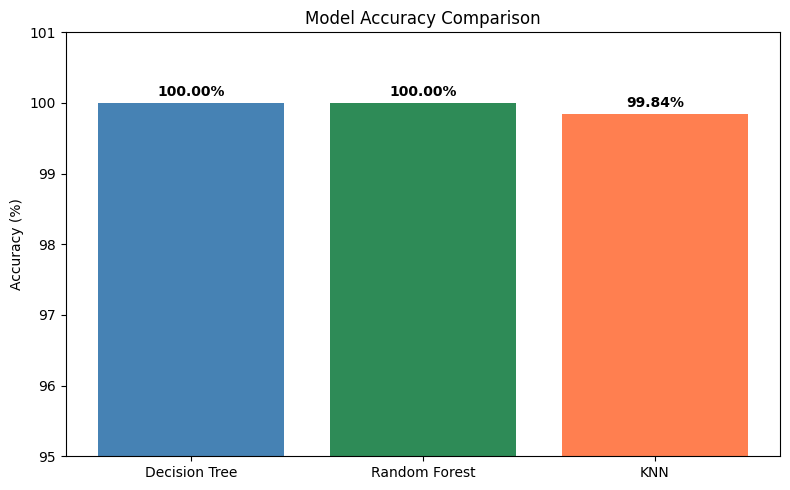

In [13]:
models = ['Decision Tree', 'Random Forest', 'KNN']
accuracies = [accuracy_dt*100, accuracy_rf*100, accuracy_knn*100]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['steelblue', 'seagreen', 'coral'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(95, 101)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.1, 
              f'{acc:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

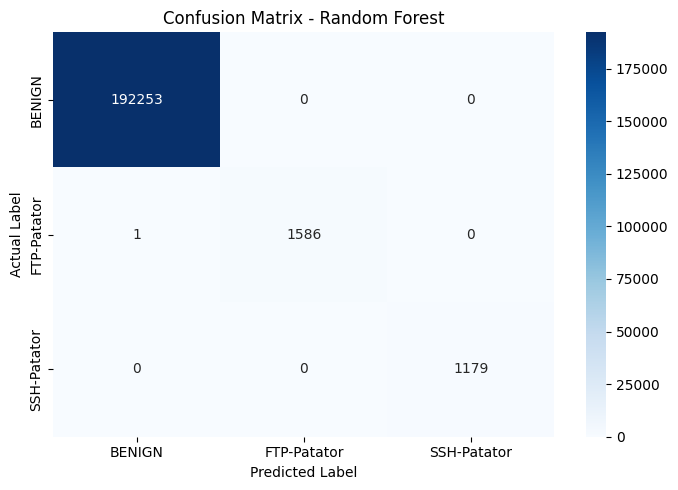

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_raw, y_pred_rf)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BENIGN', 'FTP-Patator', 'SSH-Patator'],
            yticklabels=['BENIGN', 'FTP-Patator', 'SSH-Patator'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

files = {
    'Wednesday': 'MachineLearningCvE/Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday_Morning': 'MachineLearningCvE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday_Afternoon': 'MachineLearningCvE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday_Morning': 'MachineLearningCvE/Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday_Afternoon_DDoS': 'MachineLearningCvE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Friday_Afternoon_PortScan': 'MachineLearningCvE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
}

for name, path in files.items():
    temp_df = pd.read_csv(path)
    print(f"\n{name}:")
    print(temp_df[' Label'].value_counts())


Wednesday:
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

Thursday_Morning:
 Label
BENIGN                        168186
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64

Thursday_Afternoon:
 Label
BENIGN          288566
Infiltration        36
Name: count, dtype: int64

Friday_Morning:
 Label
BENIGN    189067
Bot         1966
Name: count, dtype: int64

Friday_Afternoon_DDoS:
 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

Friday_Afternoon_PortScan:
 Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64


In [16]:
import pandas as pd

# Load all files
df_monday = pd.read_csv('MachineLearningCvE/Monday-WorkingHours.pcap_ISCX.csv')
df_tuesday = pd.read_csv('MachineLearningCvE/Tuesday-WorkingHours.pcap_ISCX.csv')
df_wednesday = pd.read_csv('MachineLearningCvE/Wednesday-workingHours.pcap_ISCX.csv')
df_thu_morning = pd.read_csv('MachineLearningCvE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')
df_thu_afternoon = pd.read_csv('MachineLearningCvE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv')
df_fri_morning = pd.read_csv('MachineLearningCvE/Friday-WorkingHours-Morning.pcap_ISCX.csv')
df_fri_ddos = pd.read_csv('MachineLearningCvE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df_fri_portscan = pd.read_csv('MachineLearningCvE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')

# Combine all into one
df_full = pd.concat([
    df_monday, df_tuesday, df_wednesday, 
    df_thu_morning, df_thu_afternoon,
    df_fri_morning, df_fri_ddos, df_fri_portscan
], ignore_index=True)

print("Full dataset shape:", df_full.shape)
print("\nAll label counts:")
print(df_full[' Label'].value_counts())

Full dataset shape: (2830743, 79)

All label counts:
 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [17]:
# Fix the encoding issue in Web Attack labels
df_full[' Label'] = df_full[' Label'].str.replace('�', '-', regex=False)

print(df_full[' Label'].value_counts())

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [18]:
df_full.to_csv('full_combined_dataset.csv', index=False)
print("Full dataset saved!")

Full dataset saved!


In [19]:
print("Before cleaning:", df_full.shape)

# Remove negative flow durations
df_full = df_full[df_full[' Flow Duration'] >= 0]

# Replace infinity values
df_full = df_full.replace([np.inf, -np.inf], np.nan)

# Drop NaN rows
df_full = df_full.dropna()

print("After cleaning:", df_full.shape)
print("\nLabel counts after cleaning:")
print(df_full[' Label'].value_counts())

Before cleaning: (2830743, 79)
After cleaning: (2827761, 79)

Label counts after cleaning:
 Label
BENIGN                        2271205
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import LabelEncoder

le_full = LabelEncoder()
df_full[' Label'] = le_full.fit_transform(df_full[' Label'])

print("Label mapping:")
for i, label in enumerate(le_full.classes_):
    print(f"{label} → {i}")

Label mapping:
BENIGN → 0
Bot → 1
DDoS → 2
DoS GoldenEye → 3
DoS Hulk → 4
DoS Slowhttptest → 5
DoS slowloris → 6
FTP-Patator → 7
Heartbleed → 8
Infiltration → 9
PortScan → 10
SSH-Patator → 11
Web Attack - Brute Force → 12
Web Attack - Sql Injection → 13
Web Attack - XSS → 14


In [21]:
from sklearn.ensemble import RandomForestClassifier

X_full = df_full.drop(' Label', axis=1)
y_full = df_full[' Label']

# Sample for speed
X_sample = X_full.sample(100000, random_state=42)
y_sample = y_full[X_sample.index]

print("Finding important features... (this may take 2-3 minutes)")
rf_temp = RandomForestClassifier(n_estimators=15, random_state=42, n_jobs=-1)
rf_temp.fit(X_sample, y_sample)

importances_full = pd.Series(rf_temp.feature_importances_, index=X_full.columns)
importances_full = importances_full.sort_values(ascending=False)

print("\nTop 20 most important features:")
print(importances_full.head(20))

Finding important features... (this may take 2-3 minutes)

Top 20 most important features:
 Total Length of Bwd Packets    0.072042
 Packet Length Variance         0.068010
 Fwd Packet Length Max          0.063312
 Subflow Fwd Bytes              0.063295
 Packet Length Std              0.062933
 Bwd Packet Length Mean         0.062227
 Max Packet Length              0.057958
 Subflow Bwd Bytes              0.049698
 Average Packet Size            0.032479
 Destination Port               0.030211
Init_Win_bytes_forward          0.028584
 Avg Bwd Segment Size           0.026173
 Packet Length Mean             0.024703
Total Length of Fwd Packets     0.022319
 Bwd Packet Length Std          0.020839
 PSH Flag Count                 0.017267
 Total Backward Packets         0.017129
Subflow Fwd Packets             0.016740
 Fwd Header Length.1            0.013850
 Fwd Header Length              0.013524
dtype: float64


In [22]:
top_20_full = importances_full.head(20).index.tolist()

X_selected_full = df_full[top_20_full]
y_full = df_full[' Label']

print("New dataset shape:", X_selected_full.shape)

# Save these feature names
pd.Series(top_20_full).to_csv('top_features_full.csv', index=False)
print("Top features saved!")

New dataset shape: (2827761, 20)
Top features saved!


In [23]:
from sklearn.model_selection import train_test_split

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_selected_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print("Train shape:", X_train_full.shape)
print("Test shape:", X_test_full.shape)

print("\nTrain label counts:")
print(y_train_full.value_counts())

Train shape: (2262208, 20)
Test shape: (565553, 20)

Train label counts:
 Label
0     1816963
4      184099
10     127043
2      102420
3        8234
7        6348
11       4717
6        4637
5        4399
1        1565
12       1206
14        522
9          29
13         17
8           9
Name: count, dtype: int64


In [24]:
from imblearn.over_sampling import SMOTE

print("Applying SMOTE... this may take several minutes given dataset size")

smote_full = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced_full, y_train_balanced_full = smote_full.fit_resample(X_train_full, y_train_full)

print("Done!")
print(pd.Series(y_train_balanced_full).value_counts())

Applying SMOTE... this may take several minutes given dataset size
Done!
 Label
0     1816963
4     1816963
10    1816963
3     1816963
2     1816963
7     1816963
5     1816963
6     1816963
11    1816963
14    1816963
1     1816963
12    1816963
9     1816963
8     1816963
13    1816963
Name: count, dtype: int64


In [26]:
from sklearn.preprocessing import StandardScaler

scaler_full = StandardScaler()
X_train_scaled_full = scaler_full.fit_transform(X_train_balanced_full)
X_test_scaled_full = scaler_full.transform(X_test_full)

print("Scaling done!")
print("Train shape:", X_train_scaled_full.shape)

Scaling done!
Train shape: (27254445, 20)


In [27]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_full_model = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1, max_depth=20)

print("Training Random Forest on 27 million rows... this WILL take several minutes, please be patient")
start_time = time.time()
rf_full_model.fit(X_train_scaled_full, y_train_balanced_full)
end_time = time.time()

print(f"Training completed in {end_time - start_time:.2f} seconds ({(end_time - start_time)/60:.2f} minutes)")

Training Random Forest on 27 million rows... this WILL take several minutes, please be patient
Training completed in 447.64 seconds (7.46 minutes)


In [28]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_full = rf_full_model.predict(X_test_scaled_full)

accuracy_full = accuracy_score(y_test_full, y_pred_full)
print(f"Random Forest Accuracy (15 classes): {accuracy_full * 100:.2f}%")

print("\nDetailed Report:")
print(classification_report(y_test_full, y_pred_full, target_names=le_full.classes_))

Random Forest Accuracy (15 classes): 98.96%

Detailed Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.99      0.99    454242
                       Bot       0.34      1.00      0.51       391
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       0.96      1.00      0.98      2059
                  DoS Hulk       0.99      1.00      1.00     46025
          DoS Slowhttptest       0.96      0.99      0.97      1100
             DoS slowloris       0.99      1.00      1.00      1159
               FTP-Patator       0.97      1.00      0.98      1587
                Heartbleed       0.67      1.00      0.80         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.99      1.00      0.99     31761
               SSH-Patator       1.00      1.00      1.00      1180
  Web Attack - Brute Force       0.08      0.20      

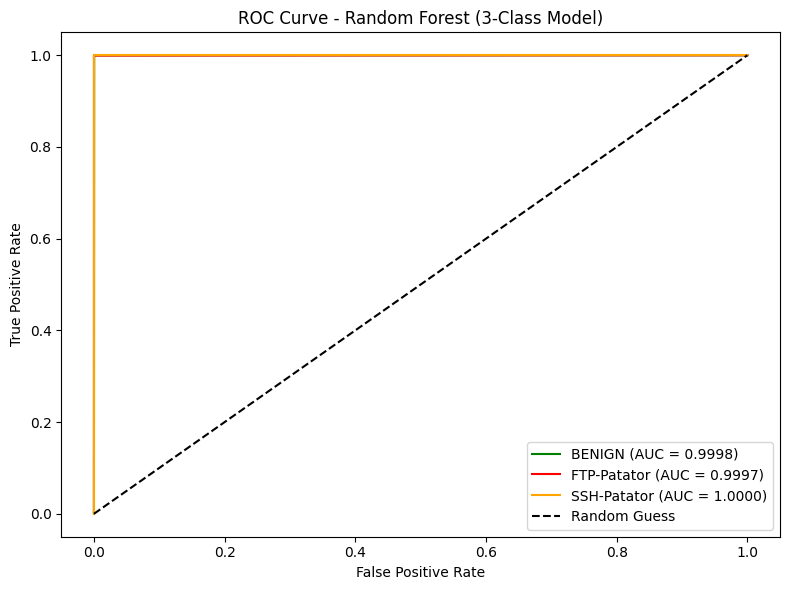

In [29]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize the labels (needed for multi-class ROC)
y_test_bin = label_binarize(y_test_raw, classes=[0, 1, 2])
y_score = rf_model.predict_proba(X_test_scaled)

class_names = ['BENIGN', 'FTP-Patator', 'SSH-Patator']
colors = ['green', 'red', 'orange']

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], 
              label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (3-Class Model)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

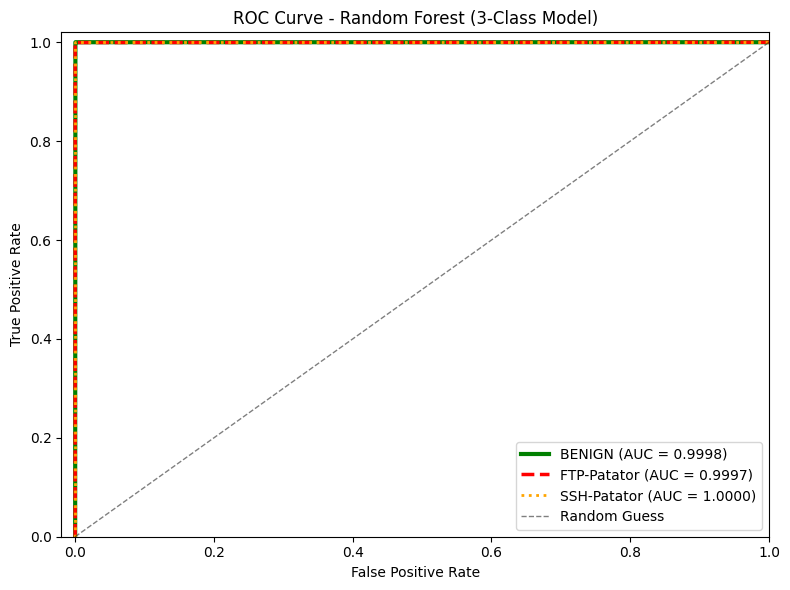

In [30]:
plt.figure(figsize=(8,6))

linestyles = ['-', '--', ':']
linewidths = [3, 2.5, 2]

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], linestyle=linestyles[i], linewidth=linewidths[i],
              label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (3-Class Model)')
plt.legend(loc='lower right')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.02])
plt.tight_layout()
plt.show()

In [31]:
import joblib
joblib.dump(rf_model, 'threat_detection_model_3class.pkl')
...
print("All models and scalers saved!")

All models and scalers saved!


In [32]:
import os
files = [f for f in os.listdir() if f.endswith('.pkl')]
print("PKL files found:")
for f in files:
    print(f"  {f} — {os.path.getsize(f)/1024/1024:.2f} MB")

PKL files found:
  threat_detection_model_3class.pkl — 0.66 MB


In [33]:
print("rf_model exists:", 'rf_model' in dir())
print("rf_full_model exists:", 'rf_full_model' in dir())
print("scaler exists:", 'scaler' in dir())
print("scaler_full exists:", 'scaler_full' in dir())
print("le_full exists:", 'le_full' in dir())

rf_model exists: True
rf_full_model exists: True
scaler exists: True
scaler_full exists: True
le_full exists: True


In [34]:
import joblib

# Save everything
joblib.dump(rf_model, 'threat_detection_model_3class.pkl')
joblib.dump(rf_full_model, 'threat_detection_model_15class.pkl')
joblib.dump(scaler, 'scaler_3class.pkl')
joblib.dump(scaler_full, 'scaler_15class.pkl')
joblib.dump(le_full, 'label_encoder_15class.pkl')

print("All models and scalers saved!")

All models and scalers saved!


In [35]:
import os
files = [f for f in os.listdir() if f.endswith('.pkl')]
print("PKL files found:")
for f in files:
    print(f"  {f} — {os.path.getsize(f)/1024/1024:.2f} MB")

PKL files found:
  label_encoder_15class.pkl — 0.00 MB
  scaler_15class.pkl — 0.00 MB
  scaler_3class.pkl — 0.00 MB
  threat_detection_model_15class.pkl — 15.08 MB
  threat_detection_model_3class.pkl — 0.66 MB
